# Pertemuan 3

Sebelum melakukan ekstraksi fitur

kita perlu memperbaiki kualitas data, kita data understanding yakni kapan data kita missing.

nah untuk mengisi data yang kosong adalah dengan data processing, salah satunya dengan menggunakan metode interpolation

interpolation sendiri adalah sebuah metode untuk mencari nilai yang tidak diketahui diantara beberapa data yang sudah diketahui

metode lain yang bisa digunakan :
- moving average


Sebelum menggunakan metode untuk mencari missing values, pastikan sudah mengidentifikasi outlier terlebih dahulu

Metode yang bisa digunakan:
- Metode statistik
- Metode Visualisasi




NOTE

Untuk tugas 2 nya, coba nanti menggunakan beberapa metode dengan teknik imputasi

jadi untuk minggu depan datanya sudah bersih



## Alur Kerja SIstem Cerdas

1. Dataset

2. Ekstraksi Fitur
  
3. Dataset Tabular



*Data yang dimiliki adalah 365, total barisnya ada 366 terhitung dengan baris fitur*


## 3 Domain Utama Ekstraksi
- Domain Statistik
    Menggambarkan distribusi dan karakteristik sentral dari amplitudo sinyal secara keseluruhan, seperti mean, variance, dan energi RMS.

- Domain Temporal
    Mengukur dinamica dan perubahan nilai seiring berjalannya waktu seperti ZCR ( Zeri Crissubg Rate) perbedaan absolut berurutan.

- Domain Spektral
    Menganalisis komposisi frekkuensi sinyal setelahan ditransformasikan ke domain frekuensi menggunakan FFT ( Fast  Fourier Transform)



Perthitungan Manual RMS


NOTE :
- Gunakan TSFEL

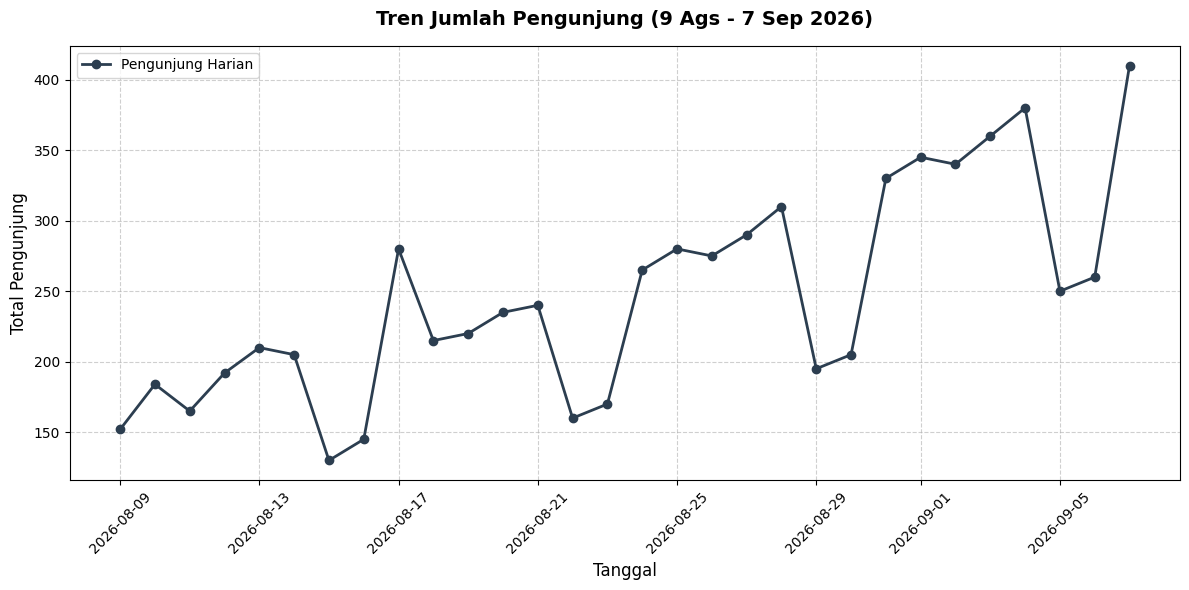

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Data time series 30 hari
data = {
    'tanggal': ['2026-08-09', '2026-08-10', '2026-08-11', '2026-08-12', '2026-08-13', 
                '2026-08-14', '2026-08-15', '2026-08-16', '2026-08-17', '2026-08-18', 
                '2026-08-19', '2026-08-20', '2026-08-21', '2026-08-22', '2026-08-23', 
                '2026-08-24', '2026-08-25', '2026-08-26', '2026-08-27', '2026-08-28', 
                '2026-08-29', '2026-08-30', '2026-08-31', '2026-09-01', '2026-09-02', 
                '2026-09-03', '2026-09-04', '2026-09-05', '2026-09-06', '2026-09-07'],
    'jumlah_pengunjung': [152, 184, 165, 192, 210, 205, 130, 145, 280, 215, 220, 235, 
                          240, 160, 170, 265, 280, 275, 290, 310, 195, 205, 330, 345, 
                          340, 360, 380, 250, 260, 410]
}

# Membuat DataFrame dan mengonversi kolom tanggal ke format datetime
df = pd.DataFrame(data)
df['tanggal'] = pd.to_datetime(df['tanggal'])

# Mengatur ukuran kanvas visualisasi
plt.figure(figsize=(12, 6))

# Memplot garis data time series
plt.plot(df['tanggal'], df['jumlah_pengunjung'], marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=6, label='Pengunjung Harian')

# Menambahkan judul dan label sumbu
plt.title('Tren Jumlah Pengunjung (9 Ags - 7 Sep 2026)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Pengunjung', fontsize=12)

# Memutar teks tanggal di sumbu X agar tidak saling bertumpuk
plt.xticks(rotation=45)

# Menambahkan gridline ringan untuk memudahkan pembacaan titik data
plt.grid(True, linestyle='--', alpha=0.6)

# Menambahkan legenda dan merapikan layout
plt.legend()
plt.tight_layout()

# Menampilkan grafik
plt.show()

In [2]:
import pandas as pd
import tsfel

# Data time series 30 hari
data = {
    'jumlah_pengunjung': [152, 184, 165, 192, 210, 205, 130, 145, 280, 215, 220, 235, 
                          240, 160, 170, 265, 280, 275, 290, 310, 195, 205, 330, 345, 
                          340, 360, 380, 250, 260, 410]
}
df = pd.DataFrame(data)

# 1. Mendapatkan konfigurasi fitur bawaan tsfel untuk domain statistik
cfg = tsfel.get_features_by_domain('statistical')

# 2. Menjalankan pipeline ekstraksi fitur (tsfel akan mengatur 'window' otomatis)
# verbose=0 digunakan untuk menyembunyikan progress bar di terminal
# Tambahkan fs=1 untuk mendefinisikan 1 sampel per hari
hasil_ekstraksi = tsfel.time_series_features_extractor(cfg, df['jumlah_pengunjung'], fs=1, verbose=0)

# 3. Mengambil secara spesifik nilai Root Mean Square (RMS) dari DataFrame hasil
# tsfel secara default menambahkan prefix "0_" untuk data 1 dimensi
rms_value = hasil_ekstraksi['0_Root mean square'].values[0]

print(f"Nilai RMS: {rms_value:.2f}")

Nilai RMS: 257.27


Total data yang kalian miliki kan 365, sedangkan fitur dari tsfel ada 68, nah gunakan data tersebut untuk digunakan pada setiap setiap fitur dari tsfel gunakan pada polutan CO, juga tampilkan bagaimana masing masing fitung bekerja dan menghitung untuk mendapatkan hasil

